# GPU Performance: MonarchLinear vs MaskedLinear

Compare forward and backward wall-clock time for the three sparse linear layer implementations
across a range of layer sizes and batch sizes, validating the motivation for the Monarch format.

Monarch matrices offer *structured* sparsity $S = P_1 M P_2$ (block-diagonal $M$ plus
random permutations) that maps naturally to GPU-friendly dense batched operations
(`torch.bmm`).

## 1. Import Required Libraries

In [1]:
import time
import warnings
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from iterativennsimple.MaskedLinear import MaskedLinear
from iterativennsimple.MonarchLinear import MonarchLinear

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory
    print(f"Total GPU memory: {total_mem / 1024**3:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 4090
Total GPU memory: 23.52 GB


## 2. Correctness Sanity Check

Before benchmarking, verify that `MonarchLinear` and a corresponding `MaskedLinear`
(initialised from the same dense weight matrix) produce identical outputs on the same input.

The Monarch layer represents $S = P_1 M P_2$.  Calling `to_dense()` materialises the
full $(\text{out} \times \text{in})$ weight matrix, which we copy into a `MaskedLinear`.

In [2]:
torch.manual_seed(42)

N = 64           # small size for correctness check
num_blocks = 4
batch = 32

# Build MonarchLinear with a fixed seed
monarch = MonarchLinear.from_uniform_blocks(N, N, num_blocks=num_blocks, 
                                            bias=True, seed=42, device=device)

# Build MaskedLinear, set weight = S exactly (weight_0 = S, U = 0, mask = 1)
masked = monarch.to_MaskedLinear()

assert masked.weight_0.shape == (N, N), f"Expected masked.weight_0 to have shape {(N, N)}, but got {masked.weight_0.shape}"

# Forward same input through both layers (CPU, eval mode)
monarch.eval()
masked.eval()
x = torch.randn(batch, N, device=device)

with torch.no_grad():
    y_monarch = monarch(x)
    y_masked  = masked(x)

# Reference: manual dense multiply
y_ref = x @ masked.weight_0.T + monarch.bias

match_monarch_ref = torch.allclose(y_monarch, y_ref, atol=1e-5)
match_monarch_masked = torch.allclose(y_monarch, y_masked, atol=1e-5)

print(f"MonarchLinear  vs manual x@S.T+b : {'PASS ✓' if match_monarch_ref    else 'FAIL ✗'}")
print(f"MonarchLinear  vs MaskedLinear   : {'PASS ✓' if match_monarch_masked  else 'FAIL ✗'}")
assert match_monarch_ref,    "MonarchLinear does not match manual dense multiply"
assert match_monarch_masked, "MonarchLinear does not match equivalent MaskedLinear"

MonarchLinear  vs manual x@S.T+b : PASS ✓
MonarchLinear  vs MaskedLinear   : PASS ✓


## 3. Benchmark Utility Functions

`benchmark_layer` measures wall-clock time for forward and backward passes using
`torch.cuda.synchronize()` barriers for accurate GPU timing.  It also records peak
GPU memory via `torch.cuda.max_memory_allocated()`.

In [3]:
def benchmark_layer(
    layer: nn.Module,
    x: torch.Tensor,
    warmup: int = 10,
    iters: int = 100,
) -> dict:
    """Benchmark forward and backward pass of a single layer.

    Args:
        layer:  The layer to benchmark (already on the correct device).
        x:      Input tensor (already on the correct device, requires_grad=False).
        warmup: Number of iterations to discard before timing.
        iters:  Number of timed iterations.

    Returns:
        dict with keys: fwd_ms, bwd_ms, total_ms, peak_mem_mb
    """
    use_cuda = x.device.type == "cuda"

    def sync() -> None:
        if use_cuda:
            torch.cuda.synchronize()

    # Reset peak memory counter
    if use_cuda:
        torch.cuda.reset_peak_memory_stats()
    mem_before = torch.cuda.max_memory_allocated() if use_cuda else 0

    # Warmup
    for _ in range(warmup):
        y = layer(x)
        loss = y.sum()
        loss.backward()
        # Zero gradients to avoid accumulation
        for p in layer.parameters():
            if p.grad is not None:
                p.grad = None
    sync()

    # Timed forward passes
    fwd_times: list[float] = []
    bwd_times: list[float] = []

    for _ in range(iters):
        sync()
        t0 = time.perf_counter()
        y = layer(x)
        sync()
        t1 = time.perf_counter()
        loss = y.sum()
        loss.backward()
        sync()
        t2 = time.perf_counter()

        fwd_times.append((t1 - t0) * 1e3)
        bwd_times.append((t2 - t1) * 1e3)

        for p in layer.parameters():
            if p.grad is not None:
                p.grad = None
    mem_after = torch.cuda.max_memory_allocated() if use_cuda else 0

    return {
        "fwd_ms":     float(np.mean(fwd_times)),
        "bwd_ms":     float(np.mean(bwd_times)),
        "total_ms":   float(np.mean(fwd_times) + np.mean(bwd_times)),
        "peak_mem_mb": (mem_after - mem_before) / 1024**2,
    }


_ALL_LAYER_TYPES = ("MaskedLinear", "MonarchLinear")


def make_layers(
    in_features: int,
    num_blocks: int,
    dev: torch.device,
    layer_types: tuple[str, ...] | list[str] | None = None,
) -> dict[str, nn.Module]:
    """Instantiate layer types with matching sparsity (~75%).

    MonarchLinear uses num_blocks (density = 1/num_blocks).
    MaskedLinear  is dense (all parameters active).

    Args:
        in_features:  Square layer dimension.
        num_blocks:   Number of Monarch blocks (8 → ~87.5% sparsity).
        dev:          Target device.
        layer_types:  Which layers to create.  Pass a list/tuple containing
                      any subset of ``("MaskedLinear", "MonarchLinear")``.
                      ``None`` (default) creates both.

    Returns:
        dict mapping layer name → layer, in the requested order.
    """
    if layer_types is None:
        layer_types = _ALL_LAYER_TYPES

    unknown = set(layer_types) - set(_ALL_LAYER_TYPES)
    if unknown:
        raise ValueError(f"Unknown layer type(s): {unknown}.  Choose from {_ALL_LAYER_TYPES}.")

    layers: dict[str, nn.Module] = {}

    if "MonarchLinear" in layer_types:
        layers["MonarchLinear"] = MonarchLinear.from_uniform_blocks(
            in_features, in_features, num_blocks=num_blocks, bias=True).to(dev)

    if "MaskedLinear" in layer_types:
        layers["MaskedLinear"] = MaskedLinear(in_features, in_features, bias=True).to(dev)

    return layers


print("Benchmark utilities defined.")

Benchmark utilities defined.


## 4. Run Benchmarks Across Layer Sizes

Iterate over layer sizes and batch sizes, instantiate each layer type, and call
`benchmark_layer`.  Results are stored in a `pandas.DataFrame` for easy analysis.

> **Note:** Benchmarking runs on the detected device.  GPU results are most meaningful;
> CPU results will show much smaller differences between layer types.

In [4]:
SIZE_LIST   = [2048, 4096, 8192, 16384]
BATCH_SIZES = [128, 512]
NUM_BLOCKS  = 2   # density = 1/2  →  ~50% sparsity
WARMUP      = 2
ITERS       = 10

records: list[dict] = []

for in_features in SIZE_LIST:
    for batch_size in BATCH_SIZES:
        print(f"  size={in_features:5d}, batch={batch_size:4d}", end="  |  ", flush=True)
        layers = make_layers(in_features, NUM_BLOCKS, device)
        x = torch.randn(batch_size, in_features, device=device)

        for name, layer in layers.items():
            layer.train()
            result = benchmark_layer(layer, x, warmup=WARMUP, iters=ITERS)
            record = {
                "layer":       name,
                "in_features": in_features,
                "batch_size":  batch_size,
                **result,
            }
            records.append(record)
            print(f"{name}: {result['total_ms']:.2f} ms", end="  ", flush=True)
            print(f"(peak mem: {result['peak_mem_mb']:.1f} MB)", end="  |  ", flush=True)

        # Free GPU memory between size combinations
        del layers, x
        if device.type == "cuda":
            torch.cuda.empty_cache()
        print()

df = pd.DataFrame(records)
print("\nDone — collected", len(df), "benchmark records.")

  size= 2048, batch= 128  |  

MonarchLinear: 0.60 ms  (peak mem: 18.1 MB)  |  MaskedLinear: 0.36 ms  (peak mem: 33.0 MB)  |  
  size= 2048, batch= 512  |  MonarchLinear: 0.67 ms  (peak mem: 24.0 MB)  |  MaskedLinear: 0.87 ms  (peak mem: 36.0 MB)  |  
  size= 4096, batch= 128  |  MonarchLinear: 0.53 ms  (peak mem: 36.0 MB)  |  MaskedLinear: 2.71 ms  (peak mem: 130.0 MB)  |  
  size= 4096, batch= 512  |  MonarchLinear: 1.38 ms  (peak mem: 56.0 MB)  |  MaskedLinear: 3.34 ms  (peak mem: 136.0 MB)  |  
  size= 8192, batch= 128  |  MonarchLinear: 0.94 ms  (peak mem: 136.0 MB)  |  MaskedLinear: 3.63 ms  (peak mem: 516.0 MB)  |  
  size= 8192, batch= 512  |  MonarchLinear: 2.03 ms  (peak mem: 160.0 MB)  |  MaskedLinear: 6.77 ms  (peak mem: 528.0 MB)  |  
  size=16384, batch= 128  |  MonarchLinear: 2.21 ms  (peak mem: 528.1 MB)  |  MaskedLinear: 13.67 ms  (peak mem: 2056.1 MB)  |  
  size=16384, batch= 512  |  MonarchLinear: 7.03 ms  (peak mem: 576.1 MB)  |  MaskedLinear: 23.41 ms  (peak mem: 2080.1 MB)  |  

Done — collect

## 5. Analyze and Display Results

In [5]:
# Display the full results table, rounded for readability
display_cols = ["layer", "in_features", "batch_size", "fwd_ms", "bwd_ms", "total_ms", "peak_mem_mb"]
pd.set_option("display.float_format", "{:.3f}".format)
print(df[display_cols].to_string(index=False))

# Compute speedup: SparseLinear total_ms / MonarchLinear total_ms
pivot = df.pivot_table(
    index=["in_features", "batch_size"],
    columns="layer",
    values="total_ms",
).reset_index()

pivot.columns.name = None
pivot["speedup_monarch_over_masked"] = pivot["MaskedLinear"] / pivot["MonarchLinear"]

# Print the speedup table, rounded for readability
print(
    pivot[["in_features", "batch_size",
           "speedup_monarch_over_masked"]]
    .to_string(index=False)
)

# Compute memory usage: SparseLinear peak_mem_mb / MonarchLinear peak_mem_mb
pivot = df.pivot_table(
    index=["in_features", "batch_size"],
    columns="layer",
    values="peak_mem_mb",
).reset_index()

pivot.columns.name = None
pivot["memory_monarch_over_masked"] = pivot["MaskedLinear"] / pivot["MonarchLinear"]

# Print the memory usage table, rounded for readability
print(
    pivot[["in_features", "batch_size",
           "memory_monarch_over_masked"]]
    .to_string(index=False)
)

        layer  in_features  batch_size  fwd_ms  bwd_ms  total_ms  peak_mem_mb
MonarchLinear         2048         128   0.225   0.377     0.602       18.134
 MaskedLinear         2048         128   0.119   0.244     0.362       33.009
MonarchLinear         2048         512   0.213   0.460     0.672       24.009
 MaskedLinear         2048         512   0.196   0.670     0.867       36.009
MonarchLinear         4096         128   0.220   0.309     0.529       36.017
 MaskedLinear         4096         128   0.814   1.894     2.708      130.017
MonarchLinear         4096         512   0.392   0.991     1.383       56.017
 MaskedLinear         4096         512   0.879   2.461     3.340      136.017
MonarchLinear         8192         128   0.528   0.409     0.937      136.032
 MaskedLinear         8192         128   2.257   1.369     3.626      516.032
MonarchLinear         8192         512   1.132   0.895     2.028      160.032
 MaskedLinear         8192         512   3.933   2.835     6.768

## 6. Plot Time vs. Layer Size (Log–Log Scale)

Each subplot corresponds to one batch size.  We plot both **forward time** and
**total (forward + backward) time** on a log–log scale for all three layer types.
Parallel lines imply the same asymptotic scaling; vertical separation reveals
constant-factor differences.

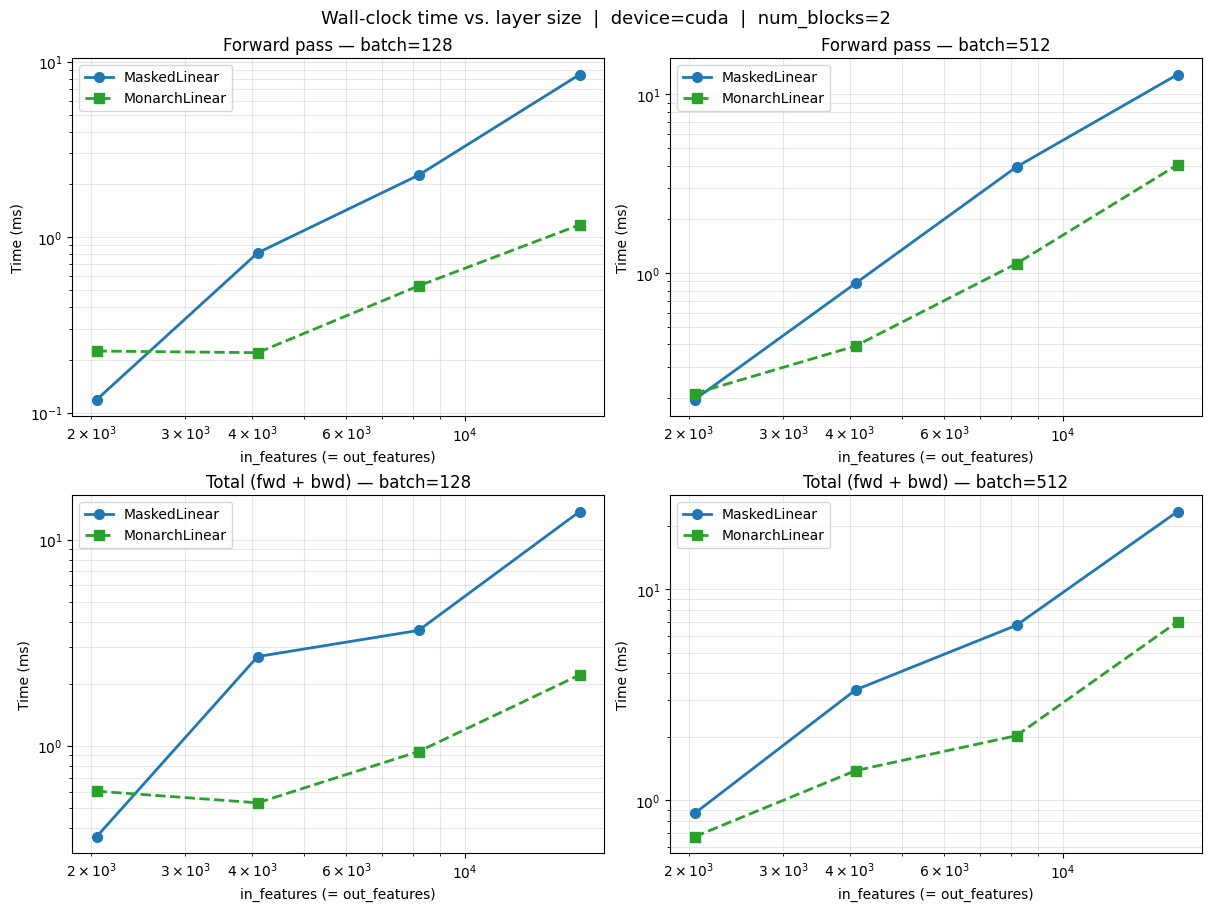

In [6]:
LAYER_STYLES = {
    "MaskedLinear": {"color": "tab:blue",   "marker": "o", "linestyle": "-"},
    "MonarchLinear":{"color": "tab:green",  "marker": "s", "linestyle": "--"},
}

fig, axes = plt.subplots(
    2, len(BATCH_SIZES),
    figsize=(6 * len(BATCH_SIZES), 9),
    constrained_layout=True,
)

for col, bs in enumerate(BATCH_SIZES):
    sub = df[df["batch_size"] == bs]

    for metric, row_idx, title in [
        ("fwd_ms",   0, "Forward pass"),
        ("total_ms", 1, "Total (fwd + bwd)"),
    ]:
        ax = axes[row_idx, col]
        for layer_name, style in LAYER_STYLES.items():
            d = sub[sub["layer"] == layer_name].sort_values("in_features")
            ax.loglog(
                d["in_features"], d[metric],
                label=layer_name,
                **style,
                linewidth=2,
                markersize=7,
            )
        ax.set_xlabel("in_features (= out_features)")
        ax.set_ylabel("Time (ms)")
        ax.set_title(f"{title} — batch={bs}")
        ax.legend()
        ax.grid(True, which="both", alpha=0.3)

fig.suptitle(
    f"Wall-clock time vs. layer size  |  device={device}  |  num_blocks={NUM_BLOCKS}",
    fontsize=13,
)
plt.savefig("time_vs_size_loglog.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Plot Memory Usage

Peak GPU memory allocated (in MB) per layer type, vs. layer size.  MonarchLinear
stores only the $k$ block weight matrices ($k \cdot (n/k)^2 = n^2/k$ parameters)
plus two permutation index arrays, so its memory footprint is $1/k$ that of a
dense layer (MaskedLinear).  SparseLinear stores COO tensors on CPU and moves
batches of values to GPU, exhibiting a different scaling pattern.

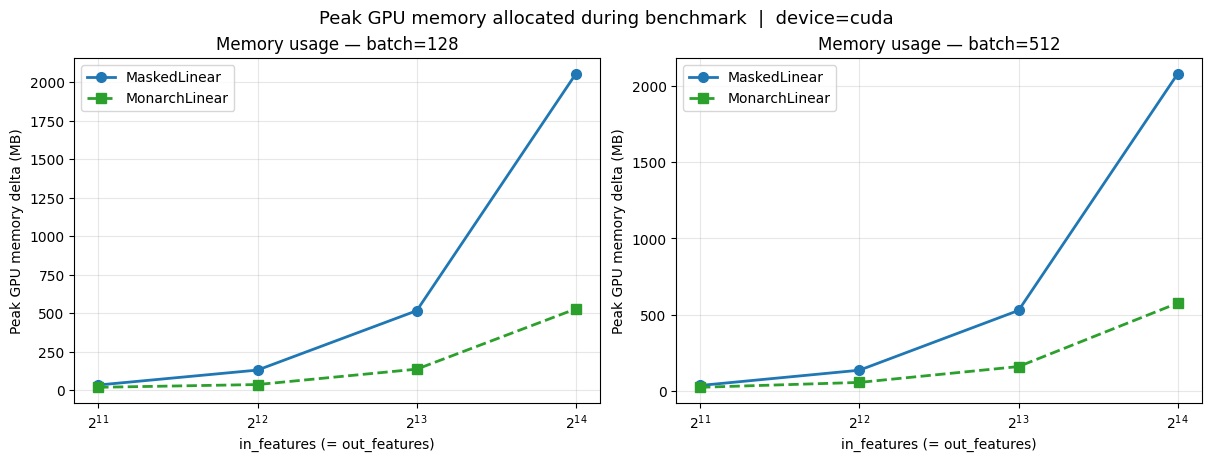

In [7]:
fig, axes = plt.subplots(1, len(BATCH_SIZES), figsize=(6 * len(BATCH_SIZES), 4.5), constrained_layout=True)

if len(BATCH_SIZES) == 1:
    axes = [axes]

for ax, bs in zip(axes, BATCH_SIZES):
    sub = df[df["batch_size"] == bs]

    for layer_name, style in LAYER_STYLES.items():
        d = sub[sub["layer"] == layer_name].sort_values("in_features")
        ax.plot(
            d["in_features"], d["peak_mem_mb"],
            label=layer_name,
            **style,
            linewidth=2,
            markersize=7,
        )

    ax.set_xscale("log", base=2)
    ax.set_xlabel("in_features (= out_features)")
    ax.set_ylabel("Peak GPU memory delta (MB)")
    ax.set_title(f"Memory usage — batch={bs}")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

fig.suptitle(f"Peak GPU memory allocated during benchmark  |  device={device}", fontsize=13)
plt.savefig("memory_usage.png", dpi=120, bbox_inches="tight")
plt.show()

if device.type != "cuda":
    print("Note: memory stats are only meaningful on CUDA.  CPU values shown are zeros.")

## 8. bmm Fast Path vs. Loop Path: MonarchLinear Internal Comparison

`MonarchLinear._block_matmul` has two code paths:
- **bmm**: uses `torch.bmm` on a stacked 3-D tensor — a single fused GPU kernel call.
- **loop**: iterates over blocks with individual `@` matmuls — multiple smaller kernel calls.

Both are mathematically identical (verified by the test suite).  This section
benchmarks the wall-clock difference across layer sizes and numbers of blocks.

In [8]:
BMM_LOOP_SIZES   = [256, 512, 1024, 2048, 4096]
BMM_LOOP_BLOCKS  = [2, 4, 8, 16]
BMM_LOOP_BATCH   = 256
WARMUP_BL        = 5
ITERS_BL         = 50

bmm_loop_records: list[dict] = []

for in_features in BMM_LOOP_SIZES:
    for num_blocks in BMM_LOOP_BLOCKS:
        if in_features % num_blocks != 0:
            continue

        layer_bmm = MonarchLinear.from_uniform_blocks(
            in_features, in_features, num_blocks=num_blocks,
            force_loop_matmul=False, bias=True, seed=0,
        ).to(device).train()

        layer_loop = MonarchLinear.from_uniform_blocks(
            in_features, in_features, num_blocks=num_blocks,
            force_loop_matmul=True, bias=True, seed=0,
        ).to(device).train()
        # Copy weights so both layers are identical
        layer_loop.load_state_dict(layer_bmm.state_dict())

        x = torch.randn(BMM_LOOP_BATCH, in_features, device=device)

        for name, layer in [("bmm", layer_bmm), ("loop", layer_loop)]:
            result = benchmark_layer(layer, x, warmup=WARMUP_BL, iters=ITERS_BL)
            bmm_loop_records.append({
                "path":        name,
                "in_features": in_features,
                "num_blocks":  num_blocks,
                **result,
            })

        del layer_bmm, layer_loop, x
        if device.type == "cuda":
            torch.cuda.empty_cache()

        bmm  = bmm_loop_records[-2]["fwd_ms"]
        loop = bmm_loop_records[-1]["fwd_ms"]
        print(f"  size={in_features:5d}  blocks={num_blocks:3d}  "
              f"bmm fwd={bmm:.3f} ms  loop fwd={loop:.3f} ms  "
              f"speedup={loop/bmm:.2f}x")

df_bl = pd.DataFrame(bmm_loop_records)
print(f"\nDone — {len(df_bl)} records.")

  size=  256  blocks=  2  bmm fwd=0.201 ms  loop fwd=0.202 ms  speedup=1.00x
  size=  256  blocks=  4  bmm fwd=0.348 ms  loop fwd=0.341 ms  speedup=0.98x
  size=  256  blocks=  8  bmm fwd=0.677 ms  loop fwd=0.733 ms  speedup=1.08x
  size=  256  blocks= 16  bmm fwd=1.372 ms  loop fwd=1.428 ms  speedup=1.04x
  size=  512  blocks=  2  bmm fwd=0.202 ms  loop fwd=0.204 ms  speedup=1.01x
  size=  512  blocks=  4  bmm fwd=0.333 ms  loop fwd=0.325 ms  speedup=0.97x
  size=  512  blocks=  8  bmm fwd=0.626 ms  loop fwd=0.638 ms  speedup=1.02x
  size=  512  blocks= 16  bmm fwd=1.556 ms  loop fwd=1.443 ms  speedup=0.93x
  size= 1024  blocks=  2  bmm fwd=0.196 ms  loop fwd=0.205 ms  speedup=1.04x
  size= 1024  blocks=  4  bmm fwd=0.342 ms  loop fwd=0.344 ms  speedup=1.00x
  size= 1024  blocks=  8  bmm fwd=0.638 ms  loop fwd=0.634 ms  speedup=0.99x
  size= 1024  blocks= 16  bmm fwd=1.692 ms  loop fwd=1.441 ms  speedup=0.85x
  size= 2048  blocks=  2  bmm fwd=0.222 ms  loop fwd=0.197 ms  speedup=0.89x

### 8a. Table: Forward-Pass Speedup of bmm over loop

In [9]:
bmm_fwd  = df_bl[df_bl["path"] == "bmm"].pivot_table(
    index="in_features", columns="num_blocks", values="fwd_ms"
)
loop_fwd = df_bl[df_bl["path"] == "loop"].pivot_table(
    index="in_features", columns="num_blocks", values="fwd_ms"
)
speedup = loop_fwd / bmm_fwd

print("Forward-pass speedup  loop_fwd / bmm_fwd  (>1 means bmm is faster):")
print(speedup.to_string(float_format="{:.2f}x".format))

Forward-pass speedup  loop_fwd / bmm_fwd  (>1 means bmm is faster):
num_blocks     2     4     8     16
in_features                        
256         1.00x 0.98x 1.08x 1.04x
512         1.01x 0.97x 1.02x 0.93x
1024        1.04x 1.00x 0.99x 0.85x
2048        0.89x 1.00x 1.07x 1.00x
4096        1.01x 0.94x 0.98x 1.26x


### 8b. Plot: Forward Time vs. Layer Size by num_blocks

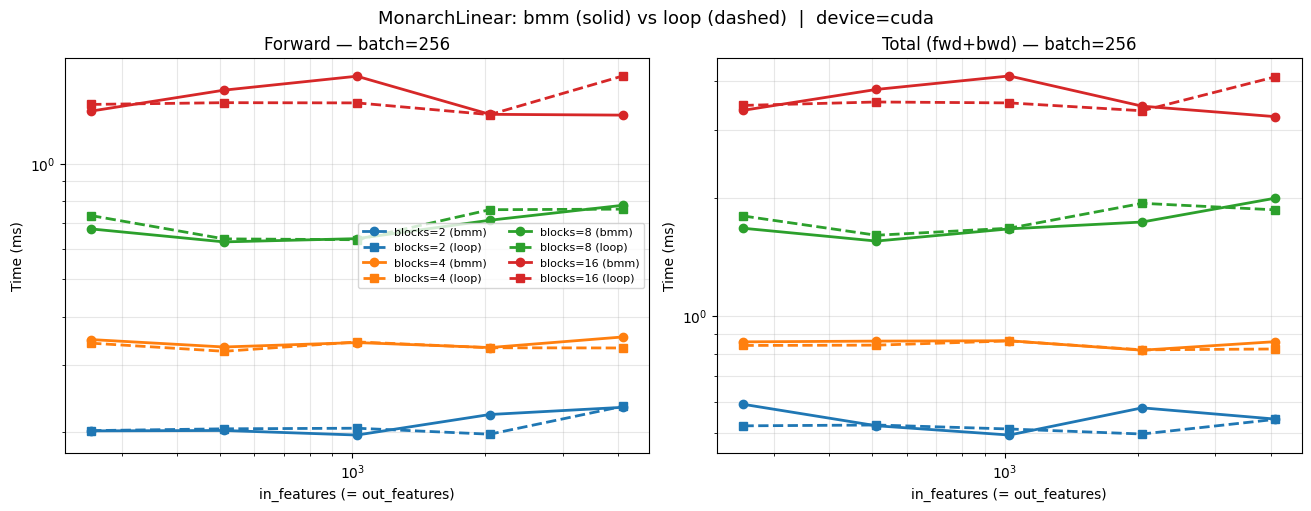

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

path_styles = {
    "bmm":  {"linestyle": "-",  "marker": "o"},
    "loop": {"linestyle": "--", "marker": "s"},
}
colors = plt.cm.tab10.colors

for ax_idx, metric in enumerate(["fwd_ms", "total_ms"]):
    ax = axes[ax_idx]
    for ci, nb in enumerate(BMM_LOOP_BLOCKS):
        color = colors[ci % len(colors)]
        for path, style in path_styles.items():
            sub = df_bl[(df_bl["path"] == path) & (df_bl["num_blocks"] == nb)].sort_values("in_features")
            if sub.empty:
                continue
            ax.loglog(
                sub["in_features"], sub[metric],
                color=color,
                label=f"blocks={nb} ({path})" if ax_idx == 0 else "_nolegend_",
                linewidth=2,
                markersize=6,
                **style,
            )
    ax.set_xlabel("in_features (= out_features)")
    ax.set_ylabel("Time (ms)")
    ax.set_title(f"{'Forward' if metric == 'fwd_ms' else 'Total (fwd+bwd)'} — batch={BMM_LOOP_BATCH}")
    ax.grid(True, which="both", alpha=0.3)

axes[0].legend(fontsize=8, ncol=2)
fig.suptitle(
    f"MonarchLinear: bmm (solid) vs loop (dashed)  |  device={device}",
    fontsize=13,
)
plt.savefig("bmm_vs_loop.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. PyTorch Profiler: Kernel-Level Analysis

The timing benchmarks above measure wall-clock time but give no insight into *which
operations* dominate.  The [PyTorch Profiler](https://pytorch.org/docs/stable/profiler.html)
records every CPU and CUDA kernel call, making it easy to identify bottlenecks.

`profile_layer` wraps a forward+backward loop in `torch.profiler.profile`.  After
`iters` profiled steps it returns a finished `Profile` object whose `.key_averages()`
method summarises self-CPU time, self-CUDA time, and memory allocations per operator.

A Chrome trace JSON is also exported — open it at `chrome://tracing` or in
[Perfetto](https://ui.perfetto.dev/) for a graphical flame-chart view.

In [11]:
from torch.profiler import ProfilerActivity, profile, record_function


def profile_layer(
    layer: nn.Module,
    x: torch.Tensor,
    layer_name: str = "layer",
    warmup: int = 5,
    iters: int = 20,
    export_trace: bool = True,
    dtype: torch.dtype | None = None,
) -> "torch.profiler.profile":
    """Profile a single layer's forward + backward pass with the PyTorch profiler.

    Args:
        layer:        Layer to profile (already on the correct device).
        x:            Input tensor (already on the correct device).
        layer_name:   Label used in record_function scopes and the trace filename.
        warmup:       Warmup steps before recording starts.
        iters:        Number of profiled steps.
        export_trace: If True, write a Chrome-format JSON trace to
                      ``{layer_name}_{dtype}_trace.json``.
        dtype:        Optional dtype to cast both the layer parameters and the
                      input tensor before profiling (e.g. ``torch.bfloat16``,
                      ``torch.float16``, ``torch.float32``).  If ``None``, the
                      layer and input are used as-is.  Note: ``nn.Module.to()``
                      is in-place, so the caller's layer will also be cast.

    Returns:
        The finished ``torch.profiler.profile`` object.
    """
    use_cuda = x.device.type == "cuda"
    activities = [ProfilerActivity.CPU]
    if use_cuda:
        activities.append(ProfilerActivity.CUDA)

    # Optionally cast to the requested precision
    if dtype is not None:
        layer = layer.to(dtype=dtype)
        x = x.to(dtype=dtype)
        dtype_name = str(dtype).replace("torch.", "")
    else:
        dtype_name = str(x.dtype).replace("torch.", "")

    # Warmup — run outside the profiler to avoid cold-start artefacts
    for _ in range(warmup):
        y = layer(x)
        y.sum().backward()
        for p in layer.parameters():
            if p.grad is not None:
                p.grad = None
    if use_cuda:
        torch.cuda.synchronize()

    with profile(
        activities=activities,
        record_shapes=True,
        profile_memory=True,
        with_stack=False,
    ) as prof:
        for _ in range(iters):
            with record_function(f"{layer_name}_fwd"):
                y = layer(x)
            with record_function(f"{layer_name}_bwd"):
                y.sum().backward()
            for p in layer.parameters():
                if p.grad is not None:
                    p.grad = None

    if export_trace:
        trace_path = f"{layer_name}_{dtype_name}_trace.json"
        prof.export_chrome_trace(trace_path)
        print(f"  Chrome trace saved → {trace_path}  (open in chrome://tracing or Perfetto)")

    return prof


print("profile_layer() defined.")

profile_layer() defined.


In [12]:
# --- Profiler configuration ---
PROF_SCALE      = 16
PROF_SIZE       = PROF_SCALE * 16 * 1024       # layer in_features / out_features
PROF_BATCH      = 128           # batch size
PROF_NUM_BLOCKS = PROF_SCALE * 8             # Monarch blocks (25 % density)
PROF_WARMUP     = 5
PROF_ITERS      = 20
PROF_DTYPE      = torch.bfloat16  # set to None to keep float32, or try torch.float16

prof_layers = make_layers(PROF_SIZE, PROF_NUM_BLOCKS, device, layer_types=["MonarchLinear"])
x_prof = torch.randn(PROF_BATCH, PROF_SIZE, device=device)

sort_key = "cuda_time_total" if device.type == "cuda" else "cpu_time_total"
dtype_label = str(PROF_DTYPE).replace("torch.", "") if PROF_DTYPE is not None else "float32"

profiler_results: dict[str, "torch.profiler.profile"] = {}

for name, layer in prof_layers.items():
    layer.train()
    print(f"\n{'='*60}")
    print(f"Profiling {name}  (size={PROF_SIZE}, batch={PROF_BATCH}, dtype={dtype_label})")
    print("=" * 60)
    prof = profile_layer(
        layer, x_prof,
        layer_name=name,
        warmup=PROF_WARMUP,
        iters=PROF_ITERS,
        export_trace=True,
        dtype=PROF_DTYPE,
    )
    profiler_results[name] = prof

    # Print the top-20 operators sorted by the dominant time dimension
    print(
        prof.key_averages().table(
            sort_by=sort_key,
            row_limit=20,
        )
    )

del prof_layers, x_prof
if device.type == "cuda":
    torch.cuda.empty_cache()


Profiling MonarchLinear  (size=262144, batch=128, dtype=bfloat16)
  Chrome trace saved → MonarchLinear_bfloat16_trace.json  (open in chrome://tracing or Perfetto)
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
autograd::engine::evaluate_function: torch::autograd...         0.73%   

In [13]:
# --- First-principles memory estimates ---
#
# For a square layer of width n = PROF_SIZE with dtype of PROF_DTYPE:
#
#   MaskedLinear  (dense)   : W  is  n × n  →  n²  elements
#   MonarchLinear (Monarch) : k blocks, each of size (n/k) × (n/k)
#                             total = k · (n/k)²  =  n²/k  elements
#
# Both layers also store two permutation index vectors of length n,
# but these are int64 (8 bytes each) and negligible vs. the weight data
# for large n.
#
# Activation (forward pass, one batch row): n elements per sample.
#   full batch : PROF_BATCH × n  elements

_dtype = PROF_DTYPE if PROF_DTYPE is not None else torch.float32
_bytes = torch.finfo(_dtype).bits // 8  if _dtype.is_floating_point else torch.iinfo(_dtype).bits // 8
n   = PROF_SIZE
k   = PROF_NUM_BLOCKS
bs  = PROF_BATCH

dense_params   = n * n
monarch_params = n * n // k
act_elements   = bs * n

def _fmt(nbytes: int) -> str:
    """Human-readable byte count: B / KB / MB / GB."""
    for unit, thr in [("GB", 1 << 30), ("MB", 1 << 20), ("KB", 1 << 10)]:
        if nbytes >= thr:
            return f"{nbytes / thr:.2f} {unit}"
    return f"{nbytes} B"

print(f"dtype : {_dtype}  ({_bytes} bytes/element)")
print(f"n     = {n:,}   k (num_blocks) = {k}   batch = {bs:,}")
print()
print("Weight matrices (parameters only, excludes bias & permutations):")
print(f"  MaskedLinear   n²       = {dense_params:>15,} elements  →  {_fmt(dense_params * _bytes)}")
print(f"  MonarchLinear  n²/k     = {monarch_params:>15,} elements  →  {_fmt(monarch_params * _bytes)}"
      f"  (reduction {k}×)")
print()
print("Activation tensor (batch × n, forward pass):")
print(f"  {bs} × {n} = {act_elements:>15,} elements  →  {_fmt(act_elements * _bytes)}")
print()
# Rough total peak memory per layer during a forward+backward pass:
# weights + gradients (~same size) + input activation + output activation
for label, nparams in [("MaskedLinear", dense_params), ("MonarchLinear", monarch_params)]:
    peak = (nparams * 2 + act_elements * 2) * _bytes   # weights + grads + in + out activations
    print(f"  Rough peak (weights + grads + activations) — {label}: {_fmt(peak)}")

dtype : torch.bfloat16  (2 bytes/element)
n     = 262,144   k (num_blocks) = 128   batch = 128

Weight matrices (parameters only, excludes bias & permutations):
  MaskedLinear   n²       =  68,719,476,736 elements  →  128.00 GB
  MonarchLinear  n²/k     =     536,870,912 elements  →  1.00 GB  (reduction 128×)

Activation tensor (batch × n, forward pass):
  128 × 262144 =      33,554,432 elements  →  64.00 MB

  Rough peak (weights + grads + activations) — MaskedLinear: 256.12 GB
  Rough peak (weights + grads + activations) — MonarchLinear: 2.12 GB
